In [1]:
import os
import glob
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Importing the observation data
obs_path = 'SBIG_obs' ## replace with local file path 
os.chdir(obs_path)
raw_darks = glob.glob('dark*.FIT')
raw_flat = glob.glob('flat*.FIT')
raw_bias = glob.glob('bias*.FIT')

frame_size=fits.getdata(raw_bias[1]).shape
gain = fits.getheader(raw_bias[1])['EGAIN']
print(f"Detector gain is {round(gain,2)} Electron per ADU")
print(f"Each frame is {frame_size[0]} x {frame_size[1]} pixels") 

Detector gain is 0.38 Electron per ADU
Each frame is 2532 x 3352 pixels


In [3]:
### bias signal and read noise ###

#calculations
bias_data = np.array([fits.getdata(fn) for fn in raw_bias])
master_bias = np.median(bias_data, axis=0)
std_bias = bias_data.std(axis=0, ddof = 1)

mean_signal = master_bias.mean()
mean_read_noise = std_bias.mean()
print(f"The mean bias signal is {mean_signal} ADU or {mean_signal * gain} electrons")
print(f"The mean read noise is {mean_read_noise} ADU or {mean_read_noise * gain} electrons")

The mean bias signal is 1048.350939006964 ADU or 398.3733568226463 electrons
The mean read noise is 26.406284165649733 ADU or 10.0343879829469 electrons


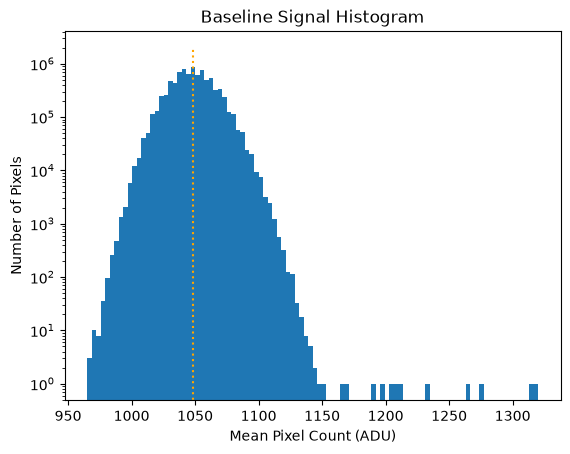

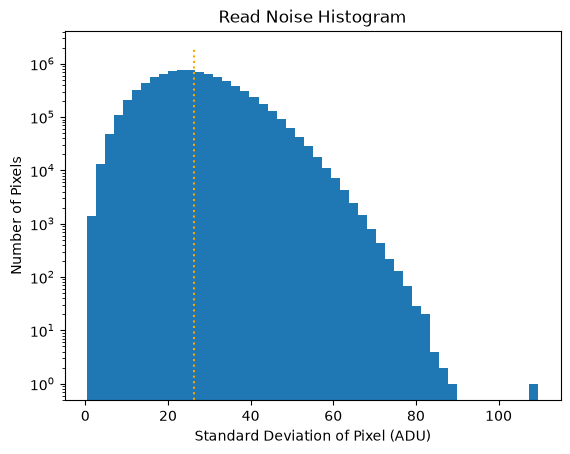

In [4]:
#graphical rep of noise and bias
mask = (master_bias >= 800) & (master_bias <= 1400)
plt.hist(master_bias[mask].ravel(), bins=100, log=True)
plt.xlabel("Mean Pixel Count (ADU)")
plt.ylabel("Number of Pixels")
plt.title("Baseline Signal Histogram")
plt.vlines(mean_signal, 0, 2e6, linestyle=":", color = "orange")
plt.show()

plt.hist(std_bias.ravel(), bins=50, log=True)
plt.xlabel("Standard Deviation of Pixel (ADU)")
plt.ylabel("Number of Pixels")
plt.title("Read Noise Histogram")
plt.vlines(mean_read_noise, 0, 2e6, linestyle=":", color = "orange")
plt.show()

In [5]:
### DARK CURRENT ###

#import frames and subtract bias signal 
dark_data = [[fits.getheader(fn)['EXPTIME'], fits.getdata(fn)-master_bias] for fn in raw_darks] # get bias substracted darks with exp time
exp_times = np.unique([fn[0] for fn in dark_data])

#median combine frames of same exposure time
master_darks = []
for time in exp_times:
    data = np.array([fn[1] for fn in dark_data if fn[0] == time])
    master_darks.append(np.median(data, axis=0))

#create a frame where each pixel contains its dark current
master_darks = np.array(master_darks)
f, y , x = master_darks.shape
expanded_darks = master_darks.reshape(5, -1)
slopes, intercepts = np.polyfit(exp_times, expanded_darks, 1)


dark_currents_ADU = slopes.reshape(y, x)
dark_current_e = dark_currents_ADU * gain  

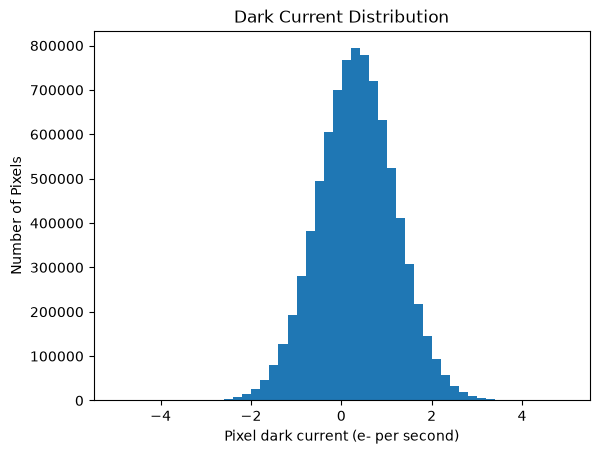

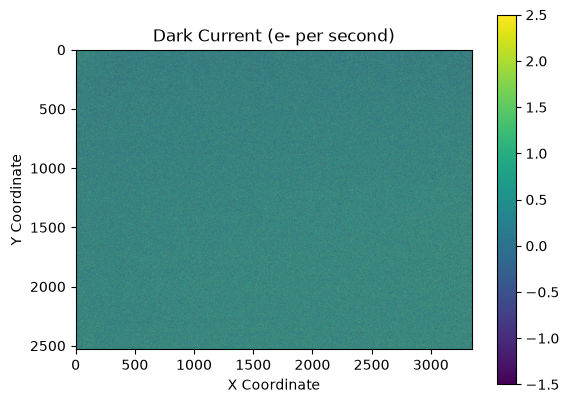

In [6]:
mask= (dark_current_e <= 5) & (dark_current_e >=-5)
plt.hist(dark_current_e[mask], bins=50)
plt.xlabel("Pixel dark current (e- per second)")
plt.ylabel("Number of Pixels")
plt.title("Dark Current Distribution")
plt.show()

plt.imshow(dark_current_e, vmax=2.5, vmin=-1.5)
plt.colorbar()
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title("Dark Current (e- per second)")
plt.show()

In [7]:
## Getting an average for Dark Current
mean_dark_current_ADU=slopes.mean()
mean_dark_current_e = slopes.mean() * gain
print(f"The dark frames taken had an average dark current of {round(mean_dark_current_ADU,3)} ADU per second")
print(f"Multiplying by the gain gives a current of {round(mean_dark_current_e,2)} electrons per second") 

The dark frames taken had an average dark current of 0.932 ADU per second
Multiplying by the gain gives a current of 0.35 electrons per second


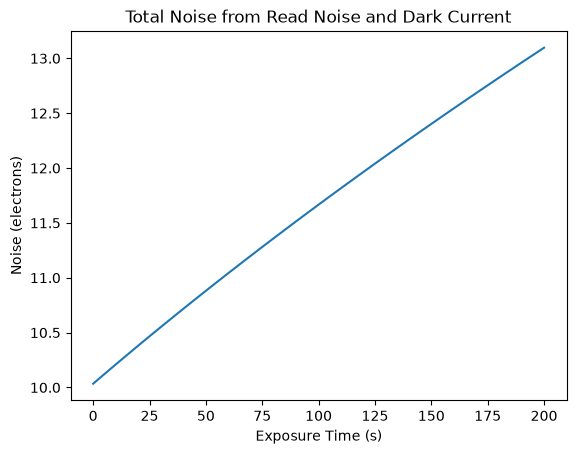

In [8]:
## Total noise from read and dark current
# noise = sqrt(read_noise^2 + D * t)
timeline = np.linspace(0, 200, 100)
noise = np.sqrt((mean_read_noise * gain)**2 + mean_dark_current_e * timeline)
plt.plot(timeline, noise)
plt.xlabel("Exposure Time (s)")
plt.ylabel("Noise (electrons)")
plt.title("Total Noise from Read Noise and Dark Current")
plt.show()

Mean pixel response variation: 13.51%


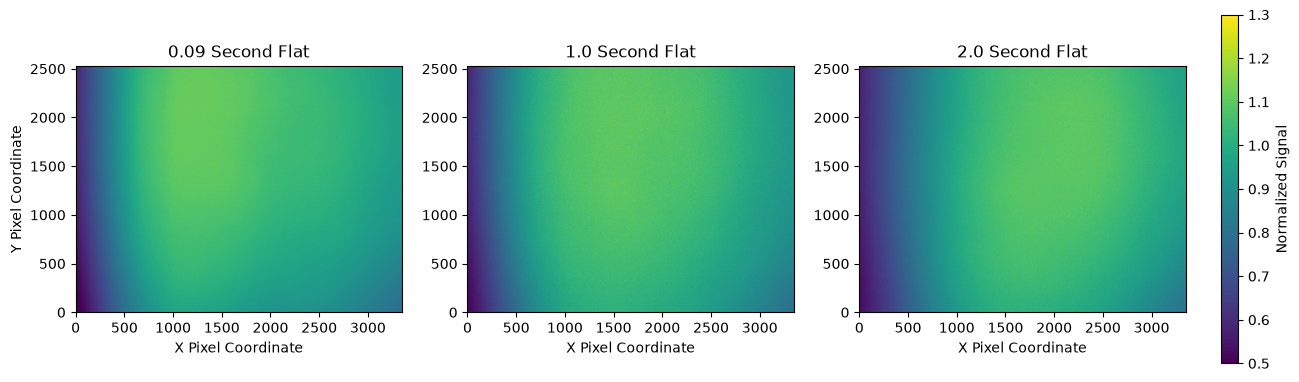

In [9]:
### Flats ##
#import frames and subtract bias signal 
flat_data = [[fits.getheader(fn)['EXPTIME'], fits.getdata(fn)-master_bias - dark_currents_ADU * fits.getheader(fn)['EXPTIME'] ] for fn in raw_flat] # get bias substracted flats with exp time
exp_times = np.unique([fn[0] for fn in flat_data])

# median combine frames of same exposure time
master_flats = []
for time in exp_times:
    data = np.array([fn[1] for fn in flat_data if fn[0] == time])
    master_flats.append(np.median(data, axis=0))
master_flats=np.array(master_flats)


# Normalize each frame with its median
median_master_flats = np.median(master_flats, axis=(1,2))
normalized_master_flats = [flat / median for flat, median in zip(master_flats, median_master_flats)]
pixel_uniformity = np.array([np.std(nmflat) for nmflat in normalized_master_flats])
print(f"Mean pixel response variation: {round(100*pixel_uniformity.mean(),2)}%")

# Graphical Representation of Pixel Variation
fig, axes = plt.subplots(1, 3, figsize=(15,30))
for i, (flat, time) in enumerate(zip(normalized_master_flats, exp_times)):
    im = axes[i].imshow(flat, vmax=1.3, vmin=0.5, origin="lower")
    axes[i].set_xlabel("X Pixel Coordinate")
    if i == 0: axes[i].set_ylabel("Y Pixel Coordinate") 
    axes[i].set_title(f"{time} Second Flat")

fig.colorbar(im, ax=axes, label = "Normalized Signal", fraction=0.015, pad = 0.03)
#plt.tight_layout()
plt.show()